# 한국 출생아수 및 합계출산율 분석
## 데이터 클랜징 → 다각도 분석 → 시각화

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
from matplotlib import rcParams
import warnings
warnings.filterwarnings('ignore')

# ============ 한글 폰트 설정 (중요!) ============
# Windows에서 사용 가능한 한글 폰트 우선순위
font_names = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
available_fonts = [font for font in font_names if font in plt.rcParams['font.sans-serif'] or True]

# 첫 번째 사용 가능한 폰트 사용
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['lines.linewidth'] = 2

# 기타 설정
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['figure.figsize'] = (12, 8)

# pandas 출력 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.unicode.ambiguous_as_wide', True)
pd.set_option('display.unicode.east_asian_width', True)

# 파일 읽기
file_path = r'c:\work\출생아수__합계출산율__자연증가_등_20240726084835.xlsx'
df = pd.read_excel(file_path)

print("=" * 80)
print("원본 데이터 정보")
print("=" * 80)
print(f"\n데이터 크기: {df.shape}")
print(f"\n컬럼명:\n{df.columns.tolist()}")
print(f"\n처음 5행:\n{df.head()}")
print(f"\n데이터 타입:\n{df.dtypes}")
print(f"\n결측치:\n{df.isnull().sum()}")

원본 데이터 정보

데이터 크기: (6, 55)

컬럼명:
['기본항목별', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023 p)']

처음 5행:
           기본항목별        1970        1971       1972       1973  \
0        출생아수(명)  1006645.00  1024773.00  952780.00  965521.00   
1    자연증가건수(명)   748056.00   787245.00  742709.00  698061.00   
2    조출생률(천명당)       31.20       31.20      28.40      28.30   
3  자연증가율(천명당)       23.20       23.90      22.20      20.50   
4      합계출산율(명)        4.53        4.54       4.12       4.07   

        1974       1975      1976       1977       1978      1979       1980  \
0  922823.00  874030.00  796331.0  825339.00 

In [37]:
# 데이터 클랜징
print("=" * 80)
print("데이터 클랜징 시작")
print("=" * 80)

print(f"\n[1] 원본 데이터 크기: {df.shape}")
print(f"    컬럼: {df.columns.tolist()[:5]}...")

# 첫 번째 컬럼이 지표명
indicator_col = df.columns[0]
print(f"\n[2] 지표명 컬럼:")
for idx, val in enumerate(df[indicator_col]):
    print(f"    {idx}: {val}")

# 데이터를 긴 형식으로 변환 (melt)
df_melted = df.melt(id_vars=[indicator_col], var_name='연도', value_name='값')

# 연도를 숫자로 변환
df_melted['연도'] = pd.to_numeric(df_melted['연도'], errors='coerce')
df_melted['값'] = pd.to_numeric(df_melted['값'], errors='coerce')

print(f"\n[3] 변환된 데이터 (긴 형식):")
print(f"    크기: {df_melted.shape}")
print(f"    처음 10행:\n{df_melted.head(10)}")

# 피벗하여 각 지표를 컬럼으로 변환
df_clean = df_melted.pivot_table(index='연도', columns=indicator_col, values='값', aggfunc='first')
df_clean = df_clean.reset_index()

print(f"\n[4] 컬럼명:")
print(f"    {df_clean.columns.tolist()}")

# 컬럼명 정규화 (한글 인코딩 처리)
new_columns = {}
for col in df_clean.columns:
    if col != '연도':
        col_str = str(col)
        if '출생' in col_str and '수' in col_str:
            new_columns[col] = '출생아수'
        elif '자연증가율' in col_str:
            new_columns[col] = '자연증가율'
        elif '합계출산율' in col_str:
            new_columns[col] = '합계출산율'
        elif '자연증가' in col_str:
            new_columns[col] = '자연증가수'
        else:
            new_columns[col] = col

df_clean = df_clean.rename(columns=new_columns)

print(f"\n[5] 정규화된 컬럼: {df_clean.columns.tolist()}")

# 연도순 정렬
df_clean = df_clean.sort_values('연도').reset_index(drop=True)

print(f"\n[6] 연도 범위: {df_clean['연도'].min():.0f} ~ {df_clean['연도'].max():.0f}")
print(f"    데이터 행 수: {len(df_clean)}")

# 결측치 정보
print(f"\n[7] 결측치 현황:")
print(df_clean.isnull().sum())

# 전역 변수 설정
year_col = '연도'
birth_cols = ['출생아수'] if '출생아수' in df_clean.columns else []
tfr_cols = ['합계출산율'] if '합계출산율' in df_clean.columns else []
df = df_clean

print(f"\n클랜징 완료!")
print(f"\n최종 데이터 (처음 10행):")
print(df.head(10))
print(f"\n최종 데이터 (마지막 5행):")
print(df.tail())
print(f"\n통계 정보:")
print(df.describe())

데이터 클랜징 시작

[1] 원본 데이터 크기: (6, 55)
    컬럼: ['기본항목별', '1970', '1971', '1972', '1973']...

[2] 지표명 컬럼:
    0: 출생아수(명)
    1: 자연증가건수(명)
    2: 조출생률(천명당)
    3: 자연증가율(천명당)
    4: 합계출산율(명)
    5: 출생성비(명)

[3] 변환된 데이터 (긴 형식):
    크기: (324, 3)
    처음 10행:
           기본항목별    연도          값
0        출생아수(명)  1970.0  1006645.00
1    자연증가건수(명)  1970.0   748056.00
2    조출생률(천명당)  1970.0       31.20
3  자연증가율(천명당)  1970.0       23.20
4      합계출산율(명)  1970.0        4.53
5        출생성비(명)  1970.0      109.50
6        출생아수(명)  1971.0  1024773.00
7    자연증가건수(명)  1971.0   787245.00
8    조출생률(천명당)  1971.0       31.20
9  자연증가율(천명당)  1971.0       23.90

[4] 컬럼명:
    ['연도', '자연증가건수(명)', '자연증가율(천명당)', '조출생률(천명당)', '출생성비(명)', '출생아수(명)', '합계출산율(명)']

[5] 정규화된 컬럼: ['연도', '자연증가수', '자연증가율', '조출생률(천명당)', '출생성비(명)', '출생아수', '합계출산율']

[6] 연도 범위: 1970 ~ 2022
    데이터 행 수: 53

[7] 결측치 현황:
기본항목별
연도                0
자연증가수          0
자연증가율          0
조출생률(천명당)    0
출생성비(명)        0
출생아수            0
합계출산율          0
dtype: 

In [39]:
# 다각도 분석
print("=" * 80)
print("다각도 분석")
print("=" * 80)

# 기본 통계
print(f"\n[1] 기본 통계")
print(df.describe())

# 출생아수 관련 통계
print(f"\n[2] 출생아수 분석")
birth_cols = [col for col in df.columns if '출생' in col]
if birth_cols:
    for col in birth_cols:
        print(f"\n{col}:")
        print(f"  - 최대값: {df[col].max():,.0f} (연도: {df[df[col] == df[col].max()][year_col].values[0]:.0f})")
        print(f"  - 최소값: {df[col].min():,.0f} (연도: {df[df[col] == df[col].min()][year_col].values[0]:.0f})")
        print(f"  - 평균: {df[col].mean():,.0f}")
        print(f"  - 표준편차: {df[col].std():,.0f}")
        print(f"  - 중앙값: {df[col].median():,.0f}")

# 합계출산율 분석
print(f"\n[3] 합계출산율 분석")
tfr_cols = [col for col in df.columns if '출산율' in col or 'TFR' in col]
if tfr_cols:
    for col in tfr_cols:
        print(f"\n{col}:")
        print(f"  - 최대값: {df[col].max():.4f} (연도: {df[df[col] == df[col].max()][year_col].values[0]:.0f})")
        print(f"  - 최소값: {df[col].min():.4f} (연도: {df[df[col] == df[col].min()][year_col].values[0]:.0f})")
        print(f"  - 평균: {df[col].mean():.4f}")
        print(f"  - 표준편차: {df[col].std():.4f}")

# 년도별 추이
print(f"\n[4] 년도별 데이터 추이")
if year_col:
    df_sorted = df.sort_values(year_col)
    print(f"\n연도 범위: {df_sorted[year_col].min():.0f} ~ {df_sorted[year_col].max():.0f}")
    print(f"분석 기간: {len(df_sorted)}년")
    print(f"\n년도별 변화율 (최근 5년):")
    if len(df_sorted) >= 5:
        recent = df_sorted.tail(5)
        print(recent[[year_col] + birth_cols + tfr_cols])

다각도 분석

[1] 기본 통계
기본항목별         연도     자연증가수  자연증가율  조출생률(천명당)  \
count         53.000000      53.000000   53.000000         53.000000   
mean        1996.000000  365388.622642    9.039623         14.892453   
std           15.443445  218599.018934    6.411298          6.978424   
min         1970.000000 -123753.000000   -2.400000          4.900000   
25%         1983.000000  213869.000000    4.300000          9.400000   
50%         1996.000000  396763.000000    9.300000         15.000000   
75%         2009.000000  498430.000000   12.900000         19.300000   
max         2022.000000  787245.000000   23.900000         31.200000   

기본항목별  출생성비(명)      출생아수  합계출산율  
count          53.000000  5.300000e+01   53.000000  
mean          108.554717  6.215370e+05    1.839868  
std             3.117295  2.030976e+05    0.984409  
min           104.200000  2.491860e+05    0.778000  
25%           105.700000  4.658920e+05    1.191000  
50%           108.200000  6.394310e+05    1.537000  
75%  

시각화: 출생아수 년도별 라인그래프


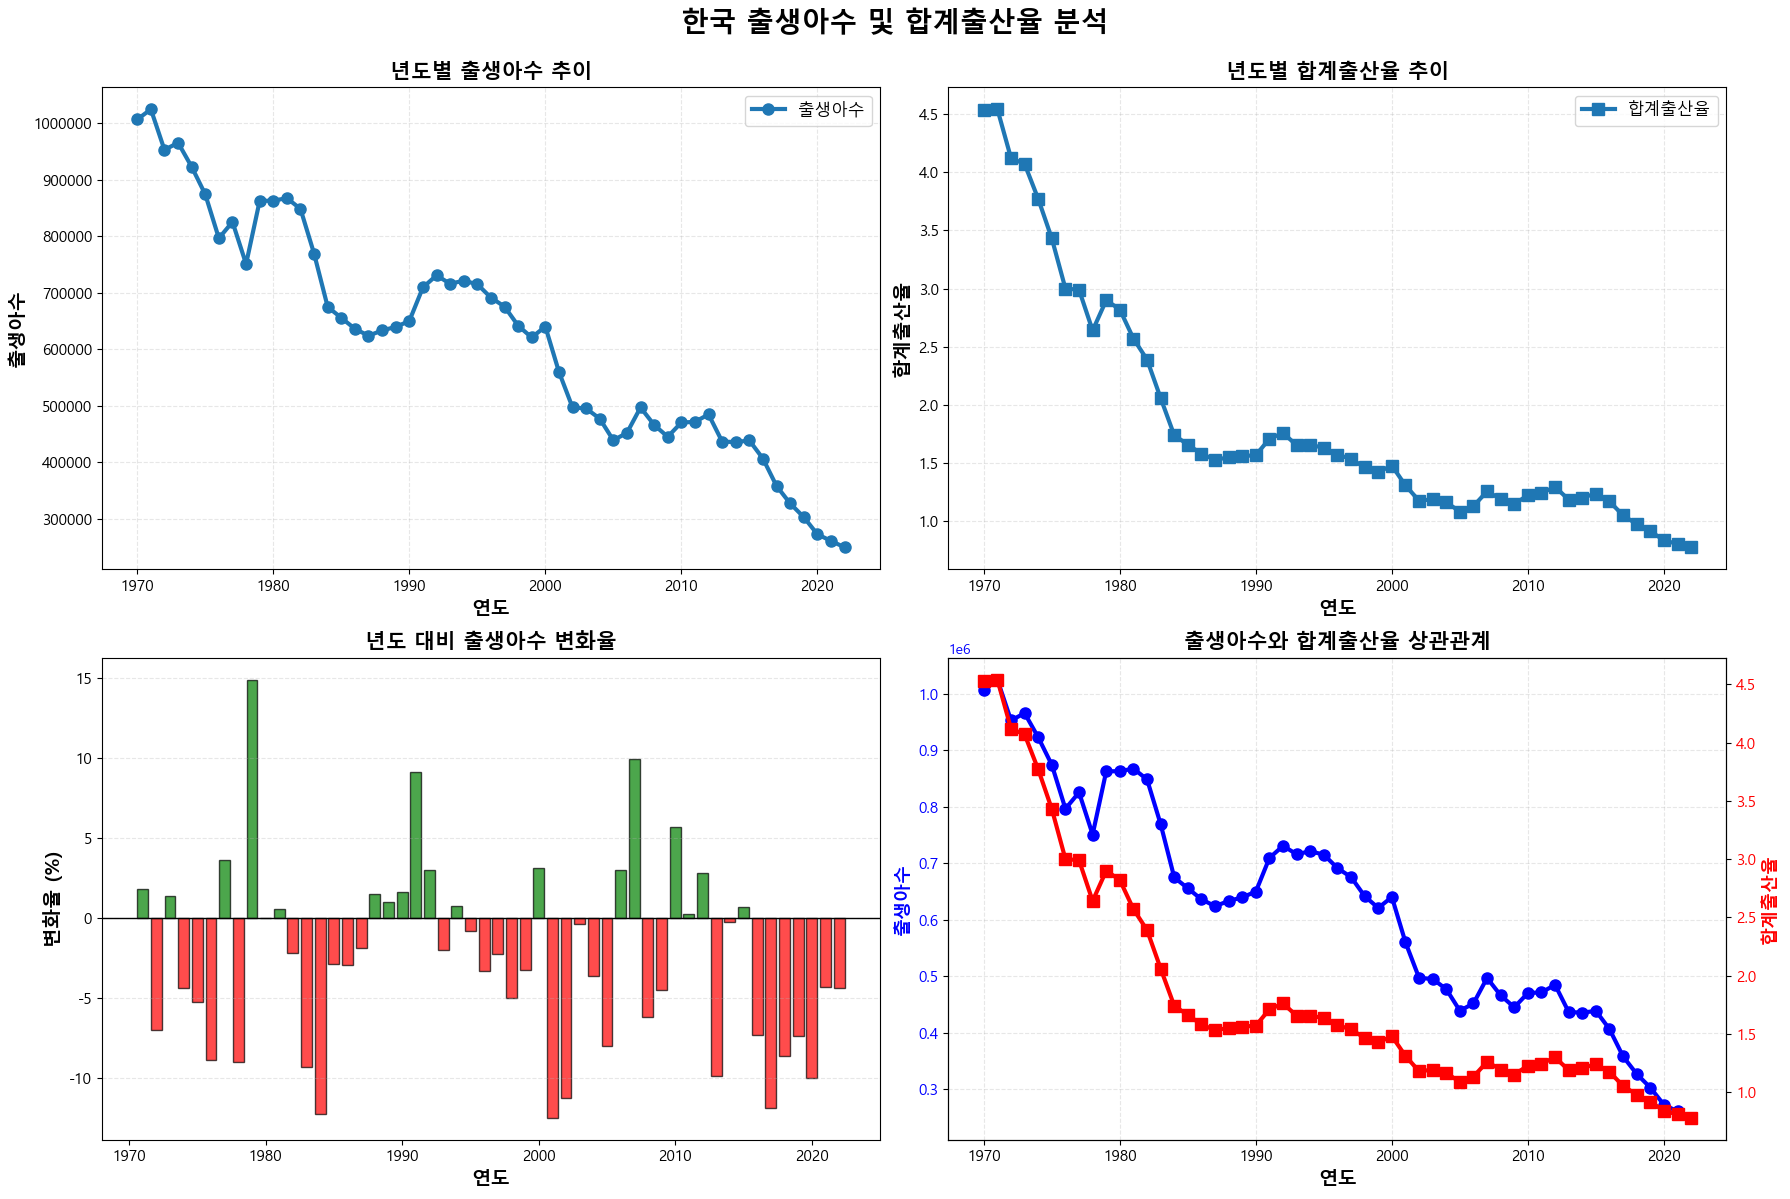


그래프가 생성되었습니다!


In [38]:
# 시각화: 출생아수 라인그래프
print("=" * 80)
print("시각화: 출생아수 년도별 라인그래프")
print("=" * 80)

if year_col and birth_cols:
    df_sorted = df.sort_values(year_col)
    
    # 여러 그래프 생성 - 크기를 더 크게 설정
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('한국 출생아수 및 합계출산율 분석', fontsize=20, fontweight='bold', y=0.995)
    
    # 1. 출생아수 라인그래프
    ax1 = axes[0, 0]
    for col in birth_cols:
        ax1.plot(df_sorted[year_col], df_sorted[col], marker='o', markersize=8, 
                linewidth=3, label=col)
    ax1.set_xlabel('연도', fontsize=14, fontweight='bold')
    ax1.set_ylabel('출생아수', fontsize=14, fontweight='bold')
    ax1.set_title('년도별 출생아수 추이', fontsize=15, fontweight='bold')
    ax1.legend(fontsize=12)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.ticklabel_format(style='plain', axis='y')
    ax1.tick_params(labelsize=11)
    
    # 2. 합계출산율 라인그래프
    ax2 = axes[0, 1]
    if tfr_cols:
        for col in tfr_cols:
            ax2.plot(df_sorted[year_col], df_sorted[col], marker='s', markersize=8,
                    linewidth=3, label=col)
    ax2.set_xlabel('연도', fontsize=14, fontweight='bold')
    ax2.set_ylabel('합계출산율', fontsize=14, fontweight='bold')
    ax2.set_title('년도별 합계출산율 추이', fontsize=15, fontweight='bold')
    ax2.legend(fontsize=12)
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.tick_params(labelsize=11)
    
    # 3. 출생아수 변화율 (년도 대비)
    ax3 = axes[1, 0]
    if birth_cols:
        main_birth_col = birth_cols[0]
        birth_change = df_sorted[main_birth_col].pct_change() * 100
        colors = ['red' if x < 0 else 'green' for x in birth_change]
        ax3.bar(df_sorted[year_col], birth_change, color=colors, alpha=0.7, edgecolor='black', linewidth=1)
        ax3.set_xlabel('연도', fontsize=14, fontweight='bold')
        ax3.set_ylabel('변화율 (%)', fontsize=14, fontweight='bold')
        ax3.set_title('년도 대비 출생아수 변화율', fontsize=15, fontweight='bold')
        ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
        ax3.grid(True, alpha=0.3, axis='y', linestyle='--')
        ax3.tick_params(labelsize=11)
    
    # 4. 출생아수와 합계출산율 이중축 그래프
    ax4 = axes[1, 1]
    if birth_cols and tfr_cols:
        ax4_twin = ax4.twinx()
        
        line1 = ax4.plot(df_sorted[year_col], df_sorted[birth_cols[0]], 
                         marker='o', markersize=8, linewidth=3, color='blue', label=birth_cols[0])
        line2 = ax4_twin.plot(df_sorted[year_col], df_sorted[tfr_cols[0]], 
                              marker='s', markersize=8, linewidth=3, color='red', label=tfr_cols[0])
        
        ax4.set_xlabel('연도', fontsize=14, fontweight='bold')
        ax4.set_ylabel('출생아수', fontsize=13, fontweight='bold', color='blue')
        ax4_twin.set_ylabel('합계출산율', fontsize=13, fontweight='bold', color='red')
        ax4.set_title('출생아수와 합계출산율 상관관계', fontsize=15, fontweight='bold')
        ax4.tick_params(axis='y', labelcolor='blue', labelsize=11)
        ax4_twin.tick_params(axis='y', labelcolor='red', labelsize=11)
        ax4.grid(True, alpha=0.3, linestyle='--')
        ax4.tick_params(axis='x', labelsize=11)
    
    plt.tight_layout()
    plt.show()
    print("\n그래프가 생성되었습니다!")

In [40]:
# 추가 분석: 상세 통계
print("=" * 80)
print("추가 분석: 상세 통계")
print("=" * 80)

if year_col and birth_cols:
    df_sorted = df.sort_values(year_col)
    main_birth_col = birth_cols[0]
    
    # 10년 단위 평균
    print(f"\n[1] 10년 단위 평균 출생아수")
    df_sorted['decade'] = (df_sorted[year_col] // 10 * 10).astype(int)
    decade_avg = df_sorted.groupby('decade')[main_birth_col].agg(['mean', 'min', 'max'])
    print(decade_avg)
    
    # 년도별 비교
    print(f"\n[2] 최근 10년과 이전 평균 비교")
    recent_10_avg = df_sorted[df_sorted[year_col] >= df_sorted[year_col].max() - 9][main_birth_col].mean()
    prev_avg = df_sorted[df_sorted[year_col] < df_sorted[year_col].max() - 9][main_birth_col].mean()
    print(f"  - 이전 평균: {prev_avg:,.0f}")
    print(f"  - 최근 10년 평균: {recent_10_avg:,.0f}")
    print(f"  - 변화: {recent_10_avg - prev_avg:+,.0f} ({(recent_10_avg/prev_avg - 1)*100:+.2f}%)")
    
    # 최고점과 최저점
    print(f"\n[3] 최고점과 최저점")
    max_idx = df_sorted[main_birth_col].idxmax()
    min_idx = df_sorted[main_birth_col].idxmin()
    print(f"  - 최고점: {df_sorted.loc[max_idx, year_col]:.0f}년 ({df_sorted.loc[max_idx, main_birth_col]:,.0f}명)")
    print(f"  - 최저점: {df_sorted.loc[min_idx, year_col]:.0f}년 ({df_sorted.loc[min_idx, main_birth_col]:,.0f}명)")
    print(f"  - 낙폭: {df_sorted.loc[max_idx, main_birth_col] - df_sorted.loc[min_idx, main_birth_col]:,.0f}명")

추가 분석: 상세 통계

[1] 10년 단위 평균 출생아수
         mean   min   max
decade                   
1970    25.87  20.3  31.2
1980    17.93  15.0  22.6
1990    15.24  13.2  16.7
2000    10.22   9.0  13.5
2010     8.14   5.9   9.6
2020     5.10   4.9   5.3

[2] 최근 10년과 이전 평균 비교
  - 이전 평균: 17
  - 최근 10년 평균: 7
  - 변화: -10 (-59.27%)

[3] 최고점과 최저점
  - 최고점: 1970년 (31명)
  - 최저점: 2022년 (5명)
  - 낙폭: 26명
